In [1]:
import pandas as pd
import numpy as np

# =========================================================
# PRE PROCESSING DATA 
# =========================================================

# =========================================================
# 1. BACA DATA
# =========================================================

df = pd.read_csv(
    "taiwan_air_quality_timeseries_cokriging_raw.csv"
)

print("Ukuran data awal:", df.shape)


# =========================================================
# 2. FORMAT WAKTU
# =========================================================

df["time"] = pd.to_datetime(df["time"])


# =========================================================
# 3. PILIH VARIABEL
# =========================================================

df["PM25"] = pd.to_numeric(
    df["PM2.5_numeric_if_valid"],
    errors="coerce"
)

df["PM10"] = pd.to_numeric(
    df["PM10_numeric_if_valid"],
    errors="coerce"
)


# =========================================================
# 4. CEK MISSING VALUE
# =========================================================

print("\nMissing value:")
print(df[["PM25", "PM10"]].isnull().sum())


# =========================================================
# 5. CLEANING
# hanya PM2.5 dan PM10 yang sama-sama tersedia
# =========================================================

df_clean = df.dropna(
    subset=["PM25", "PM10"]
).copy()


# =========================================================
# 6. HAPUS NILAI NEGATIF JIKA ADA
# =========================================================

df_clean = df_clean[
    (df_clean["PM25"] >= 0) &
    (df_clean["PM10"] >= 0)
].copy()


# =========================================================
# 7. INFORMASI WAKTU
# =========================================================

df_clean["year"] = df_clean["time"].dt.year
df_clean["month"] = df_clean["time"].dt.month


# =========================================================
# 8. STATISTIK DESKRIPTIF
# =========================================================

print("\nStatistik PM2.5 dan PM10:")
print(df_clean[["PM25", "PM10"]].describe())


# =========================================================
# 9. KORELASI TIME SERIES
# =========================================================

print(
    "\nKorelasi seluruh observasi:",
    df_clean["PM25"].corr(df_clean["PM10"])
)


# =========================================================
# 10. AGREGASI PER STASIUN
# =========================================================

df_station = (
    df_clean
    .groupby("station")
    .agg(
        longitude=("longitude_twd97", "first"),
        latitude=("latitude_twd97", "first"),
        X=("x_twd97_tm2_m", "first"),
        Y=("y_twd97_tm2_m", "first"),
        PM25=("PM25", "mean"),
        PM10=("PM10", "mean"),
        jumlah_observasi=("PM25", "count")
    )
    .reset_index()
)


# =========================================================
# 11. KORELASI ANTAR LOKASI
# =========================================================

print(
    "\nKorelasi spasial PM2.5-PM10:",
    df_station["PM25"].corr(df_station["PM10"])
)


# =========================================================
# 12. LIHAT DATA AKHIR
# =========================================================

print("\nDataset akhir Co-Kriging:")
print(df_station.round(3))


# =========================================================
# 13. SIMPAN DATA
# =========================================================

df_clean.to_csv(
    "taiwan_air_quality_clean.csv",
    index=False
)

df_station.to_csv(
    "taiwan_air_quality_cokriging_station.csv",
    index=False
)

print("\nProcessing selesai.")
print("Jumlah observasi bersih:", len(df_clean))
print("Jumlah lokasi:", len(df_station))

Ukuran data awal: (218640, 13)

Missing value:
PM25    8518
PM10    6596
dtype: int64

Statistik PM2.5 dan PM10:
                PM25           PM10
count  208782.000000  208782.000000
mean       18.590741      41.812014
std        13.360173      23.861459
min         0.000000       0.000000
25%         9.000000      26.000000
50%        16.000000      37.000000
75%        24.000000      52.000000
max       131.000000     292.000000

Korelasi seluruh observasi: 0.803288224033271

Korelasi spasial PM2.5-PM10: 0.3140177152953808

Dataset akhir Co-Kriging:
      station  longitude  latitude           X            Y    PM25    PM10  \
0     Banqiao    121.459    25.013  296293.303  2767292.715  20.259  44.209   
1     Cailiao    121.481    25.069  298528.200  2773500.941  15.857  38.679   
2      Datong    121.513    25.063  301787.522  2772876.013  17.376  53.307   
3      Dayuan    121.202    25.060  270360.868  2772476.590  20.534  46.988   
4     Guanyin    121.083    25.036  258351.49

In [3]:
%pip install scikit-gstat

Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/710.4 kB ? eta -:--:--
   -------------- ------------------------- 262.1/710.4 kB ? eta -:--:--
   ----------------------------- ---------- 524.3/710.4 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 710.4/710.4 kB 1.2 MB/s  0:00:00
   ---------------------------------------- 0.0/38.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.6 MB ? eta -:--:--
    --------------------------------------- 0.8/38.6 MB 1.2 MB/s eta 0:00:31
   - -------------------------------------- 1.0/38.6 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.3/38.6 MB 1.3 MB/s eta 0:00:29
   - -------------------------------------- 1.6/38.6 MB 1.4 MB/s eta 0:00:28
   - ---------------------------------

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


INFORMASI DATA

Ukuran data: (25, 8)

5 data pertama:
   station   longitude   latitude           X            Y       PM25  \
0  Banqiao  121.458667  25.012972  296293.303  2767292.715  20.259347   
1  Cailiao  121.481028  25.068950  298528.200  2773500.941  15.857261   
2   Datong  121.513311  25.063200  301787.522  2772876.013  17.376093   
3   Dayuan  121.201811  25.060344  270360.868  2772476.590  20.534460   
4  Guanyin  121.082761  25.035503  258351.495  2769712.502  19.043147   

        PM10  jumlah_observasi  
0  44.208502              8398  
1  38.679339              8470  
2  53.306589              8575  
3  46.988178              8459  
4  50.850616              8274  

Jumlah stasiun: 25

STATISTIK DESKRIPTIF
            PM25       PM10
count  25.000000  25.000000
mean   18.582567  41.780683
std     2.444032   8.399669
min    12.012839  17.237766
25%    17.603797  37.359054
50%    18.509853  40.333807
75%    20.534460  47.058921
max    23.153691  55.782006

Median PM2.5 :

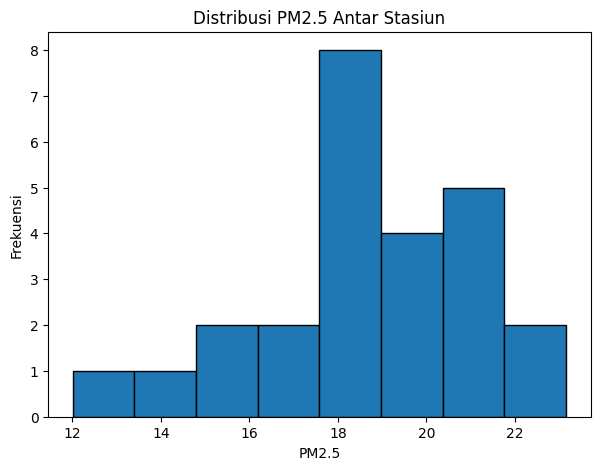

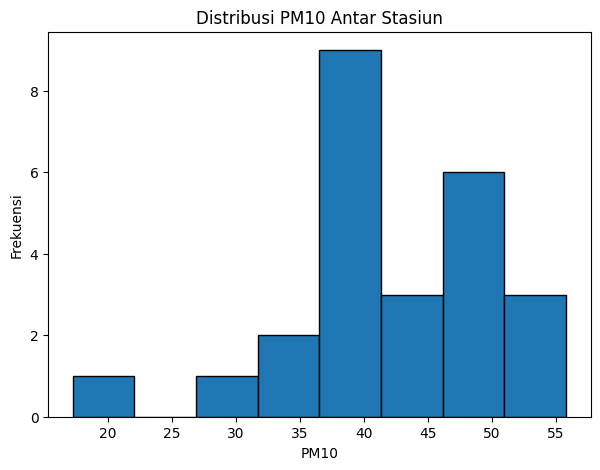

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6460\2665380254.py:166: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


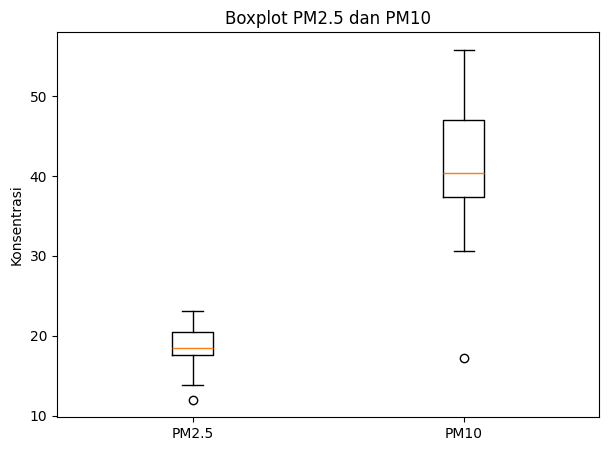

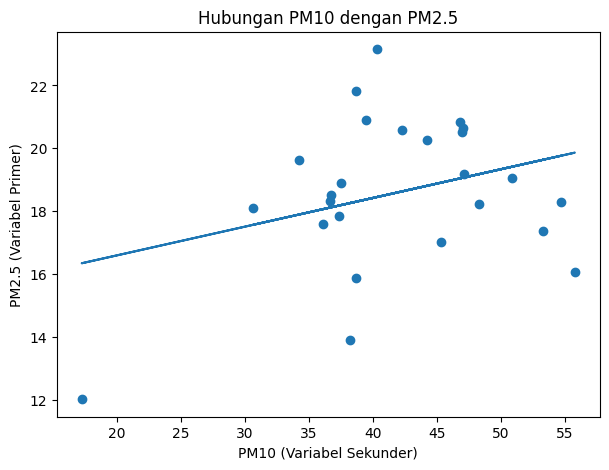

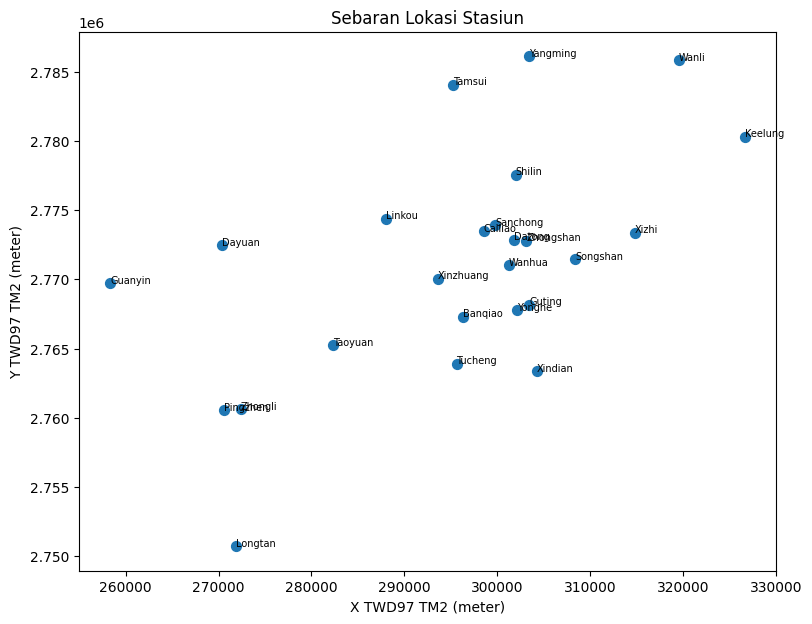

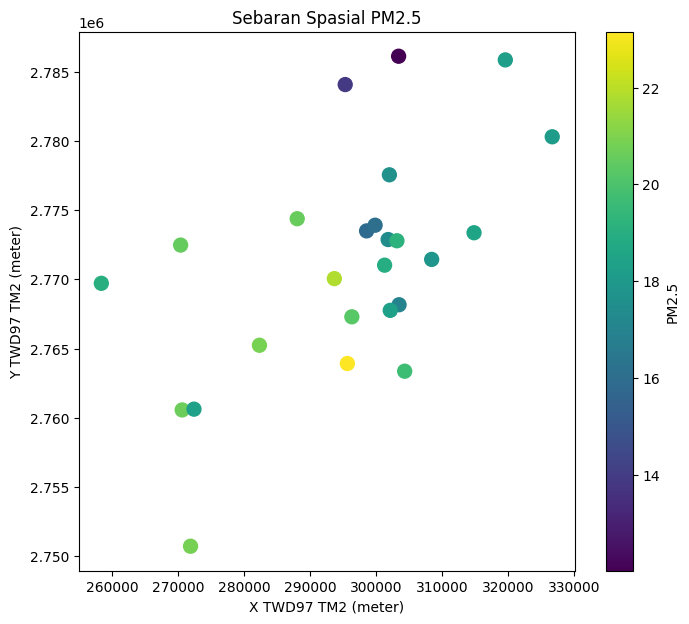

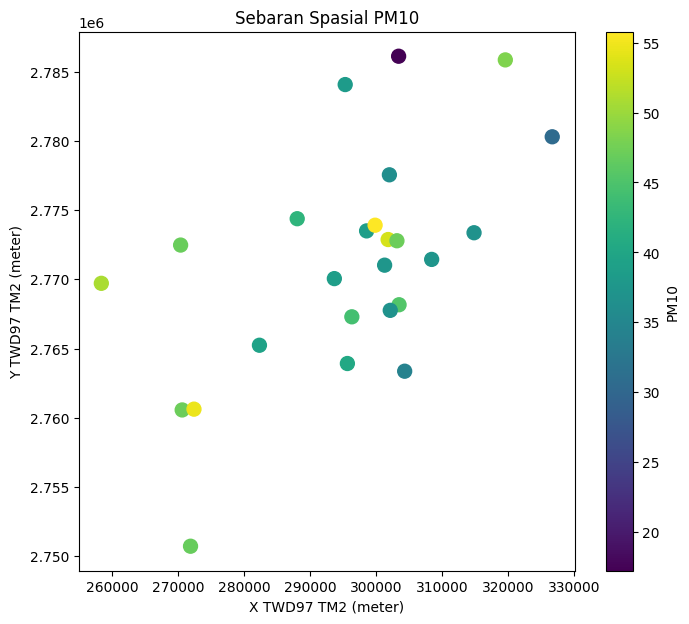


JARAK ANTAR STASIUN
Jarak minimum : 1.34 km
Jarak maksimum: 69.11 km
Jarak rata-rata: 21.89 km


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\skgstat\plotting\variogram_plot.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


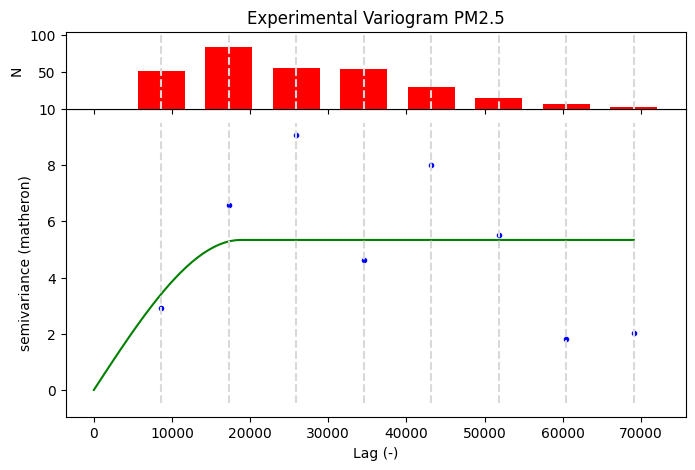


Parameter Variogram PM2.5:
[np.float64(18807.716440888904), np.float64(5.338930004965239), 0]


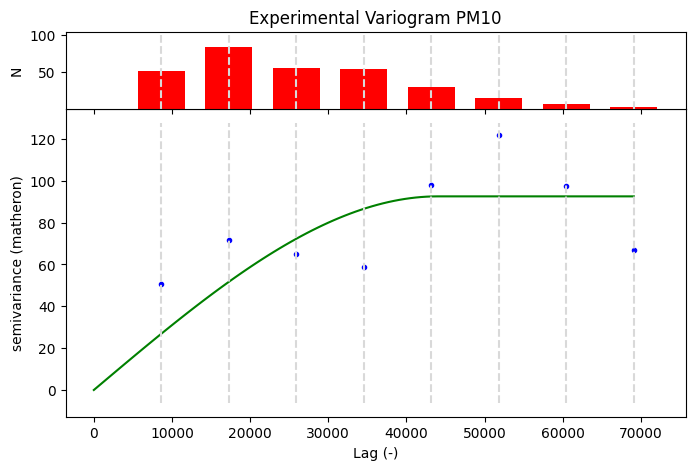


Parameter Variogram PM10:
[np.float64(44010.693983573474), np.float64(92.54091813925626), 0]


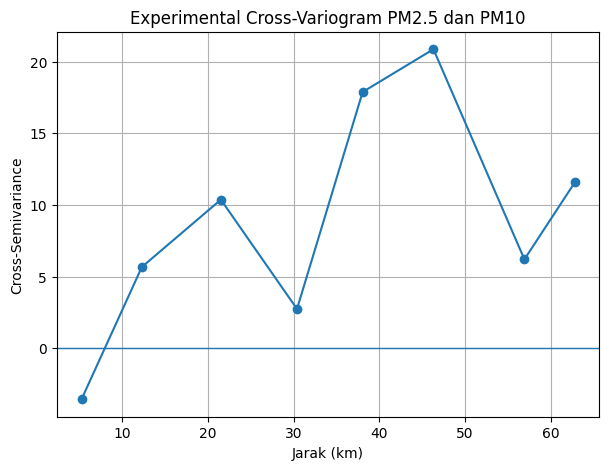


CROSS-VARIOGRAM
   Jarak_km  Cross_Semivariance  Jumlah_Pasangan
0    5.2997             -3.5590               52
1   12.3260              5.6665               84
2   21.5334             10.3652               55
3   30.4040              2.7380               54
4   38.0529             17.8748               30
5   46.3019             20.8590               15
6   56.9019              6.1973                7
7   62.7675             11.5614                2


In [4]:
# ============================================================
# TAHAP 2 - EKSPLORASI DATA DAN ANALISIS SPASIAL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import shapiro
from scipy.spatial.distance import pdist
from skgstat import Variogram


# ============================================================
# 1. BACA DATA HASIL PREPROCESSING
# ============================================================

df = pd.read_csv("taiwan_air_quality_cokriging_station.csv")

print("=" * 60)
print("INFORMASI DATA")
print("=" * 60)

print("\nUkuran data:", df.shape)
print("\n5 data pertama:")
print(df.head())

print("\nJumlah stasiun:", df["station"].nunique())


# ============================================================
# 2. STATISTIK DESKRIPTIF
# ============================================================

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)

print(df[["PM25", "PM10"]].describe())

print("\nMedian PM2.5 :", df["PM25"].median())
print("Median PM10  :", df["PM10"].median())


# ============================================================
# 3. CEK OUTLIER DENGAN METODE IQR
# ============================================================

def cek_outlier(data, kolom):

    Q1 = data[kolom].quantile(0.25)
    Q3 = data[kolom].quantile(0.75)

    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outlier = data[
        (data[kolom] < batas_bawah) |
        (data[kolom] > batas_atas)
    ]

    print(f"\nOutlier {kolom}:")
    print("Batas bawah :", batas_bawah)
    print("Batas atas  :", batas_atas)

    if len(outlier) == 0:
        print("Tidak ditemukan outlier.")
    else:
        print(outlier[["station", kolom]])

    return outlier


outlier_PM25 = cek_outlier(df, "PM25")
outlier_PM10 = cek_outlier(df, "PM10")


# ============================================================
# 4. KORELASI PM2.5 DAN PM10
# ============================================================

print("\n" + "=" * 60)
print("KORELASI PM2.5 DAN PM10")
print("=" * 60)

pearson = df["PM25"].corr(
    df["PM10"],
    method="pearson"
)

spearman = df["PM25"].corr(
    df["PM10"],
    method="spearman"
)

print("Pearson  :", round(pearson, 4))
print("Spearman :", round(spearman, 4))


# ============================================================
# 5. UJI NORMALITAS SHAPIRO-WILK
# ============================================================

print("\n" + "=" * 60)
print("UJI NORMALITAS SHAPIRO-WILK")
print("=" * 60)

shapiro_PM25 = shapiro(df["PM25"])
shapiro_PM10 = shapiro(df["PM10"])

print("\nPM2.5")
print("Statistic :", round(shapiro_PM25.statistic, 4))
print("p-value   :", round(shapiro_PM25.pvalue, 4))

print("\nPM10")
print("Statistic :", round(shapiro_PM10.statistic, 4))
print("p-value   :", round(shapiro_PM10.pvalue, 4))


# ============================================================
# 6. HISTOGRAM PM2.5
# ============================================================

plt.figure(figsize=(7, 5))

plt.hist(
    df["PM25"],
    bins=8,
    edgecolor="black"
)

plt.xlabel("PM2.5")
plt.ylabel("Frekuensi")
plt.title("Distribusi PM2.5 Antar Stasiun")

plt.show()


# ============================================================
# 7. HISTOGRAM PM10
# ============================================================

plt.figure(figsize=(7, 5))

plt.hist(
    df["PM10"],
    bins=8,
    edgecolor="black"
)

plt.xlabel("PM10")
plt.ylabel("Frekuensi")
plt.title("Distribusi PM10 Antar Stasiun")

plt.show()


# ============================================================
# 8. BOXPLOT PM2.5 DAN PM10
# ============================================================

plt.figure(figsize=(7, 5))

plt.boxplot(
    [df["PM25"], df["PM10"]],
    labels=["PM2.5", "PM10"]
)

plt.ylabel("Konsentrasi")
plt.title("Boxplot PM2.5 dan PM10")

plt.show()


# ============================================================
# 9. SCATTER PLOT PM10 vs PM2.5
# ============================================================

x = df["PM10"]
y = df["PM25"]

# garis tren
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

plt.figure(figsize=(7, 5))

plt.scatter(x, y)

plt.plot(
    x,
    trend(x)
)

plt.xlabel("PM10 (Variabel Sekunder)")
plt.ylabel("PM2.5 (Variabel Primer)")
plt.title("Hubungan PM10 dengan PM2.5")

plt.show()


# ============================================================
# 10. SEBARAN LOKASI STASIUN
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    df["X"],
    df["Y"],
    s=50
)

for i, row in df.iterrows():

    plt.text(
        row["X"],
        row["Y"],
        row["station"],
        fontsize=7
    )

plt.xlabel("X TWD97 TM2 (meter)")
plt.ylabel("Y TWD97 TM2 (meter)")
plt.title("Sebaran Lokasi Stasiun")

plt.show()


# ============================================================
# 11. SEBARAN SPASIAL PM2.5
# ============================================================

plt.figure(figsize=(8, 7))

sc = plt.scatter(
    df["X"],
    df["Y"],
    c=df["PM25"],
    s=100
)

plt.colorbar(
    sc,
    label="PM2.5"
)

plt.xlabel("X TWD97 TM2 (meter)")
plt.ylabel("Y TWD97 TM2 (meter)")
plt.title("Sebaran Spasial PM2.5")

plt.show()


# ============================================================
# 12. SEBARAN SPASIAL PM10
# ============================================================

plt.figure(figsize=(8, 7))

sc = plt.scatter(
    df["X"],
    df["Y"],
    c=df["PM10"],
    s=100
)

plt.colorbar(
    sc,
    label="PM10"
)

plt.xlabel("X TWD97 TM2 (meter)")
plt.ylabel("Y TWD97 TM2 (meter)")
plt.title("Sebaran Spasial PM10")

plt.show()


# ============================================================
# 13. JARAK ANTAR STASIUN
# ============================================================

coordinates = df[
    ["X", "Y"]
].values

distance = pdist(coordinates)

print("\n" + "=" * 60)
print("JARAK ANTAR STASIUN")
print("=" * 60)

print(
    "Jarak minimum :",
    round(distance.min() / 1000, 2),
    "km"
)

print(
    "Jarak maksimum:",
    round(distance.max() / 1000, 2),
    "km"
)

print(
    "Jarak rata-rata:",
    round(distance.mean() / 1000, 2),
    "km"
)


# ============================================================
# 14. VARIOGRAM PM2.5
# ============================================================

pm25 = df["PM25"].values

V_PM25 = Variogram(
    coordinates,
    pm25,
    n_lags=8,
    model="spherical",
    normalize=False
)

V_PM25.plot()

plt.title(
    "Experimental Variogram PM2.5"
)

plt.show()

print("\nParameter Variogram PM2.5:")
print(V_PM25.parameters)


# ============================================================
# 15. VARIOGRAM PM10
# ============================================================

pm10 = df["PM10"].values

V_PM10 = Variogram(
    coordinates,
    pm10,
    n_lags=8,
    model="spherical",
    normalize=False
)

V_PM10.plot()

plt.title(
    "Experimental Variogram PM10"
)

plt.show()

print("\nParameter Variogram PM10:")
print(V_PM10.parameters)


# ============================================================
# 16. CROSS-VARIOGRAM PM2.5 DAN PM10
# ============================================================

z1 = df["PM25"].values
z2 = df["PM10"].values

distances = []
cross_semivariance = []

n = len(df)

for i in range(n):

    for j in range(i + 1, n):

        # jarak antara stasiun i dan j
        dx = coordinates[i, 0] - coordinates[j, 0]
        dy = coordinates[i, 1] - coordinates[j, 1]

        d = np.sqrt(dx**2 + dy**2)

        # cross-semivariance
        gamma_cross = 0.5 * (
            (z1[i] - z1[j]) *
            (z2[i] - z2[j])
        )

        distances.append(d)
        cross_semivariance.append(gamma_cross)


distances = np.array(distances)

cross_semivariance = np.array(
    cross_semivariance
)


# ============================================================
# 17. MEMBUAT KELAS JARAK (LAG)
# ============================================================

n_lags = 8

bins = np.linspace(
    0,
    distances.max(),
    n_lags + 1
)

lag_distance = []
cross_gamma = []
jumlah_pasangan = []

for i in range(n_lags):

    mask = (
        (distances >= bins[i]) &
        (distances < bins[i + 1])
    )

    if mask.sum() > 0:

        lag_distance.append(
            distances[mask].mean()
        )

        cross_gamma.append(
            cross_semivariance[mask].mean()
        )

        jumlah_pasangan.append(
            mask.sum()
        )


# ============================================================
# 18. PLOT CROSS-VARIOGRAM
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    np.array(lag_distance) / 1000,
    cross_gamma,
    marker="o"
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.xlabel("Jarak (km)")
plt.ylabel("Cross-Semivariance")

plt.title(
    "Experimental Cross-Variogram PM2.5 dan PM10"
)

plt.grid()

plt.show()


# ============================================================
# 19. TABEL CROSS-VARIOGRAM
# ============================================================

cross_variogram = pd.DataFrame({

    "Jarak_km":
        np.array(lag_distance) / 1000,

    "Cross_Semivariance":
        cross_gamma,

    "Jumlah_Pasangan":
        jumlah_pasangan
})

print("\n" + "=" * 60)
print("CROSS-VARIOGRAM")
print("=" * 60)

print(cross_variogram.round(4))






Jumlah titik: 25

PERBANDINGAN VARIOGRAM PM2.5
  Variabel        Model      RMSE        RSS  \
0    PM2.5     gaussian  2.418517  46.793810   
1    PM2.5  exponential  2.541543  51.675519   
2    PM2.5       matern  2.541543  51.675519   
3    PM2.5    spherical  2.541543  51.675519   

                                           Parameter  
0  [np.float64(17881.64647005257), np.float64(5.3...  
1  [np.float64(392.2160957004089), np.float64(1.8...  
2  [np.float64(311.35559188981097), np.float64(0....  
3  [np.float64(8438.720493563356), np.float64(1.1...  

PERBANDINGAN VARIOGRAM PM10
  Variabel        Model       RMSE          RSS  \
0     PM10    spherical  17.105746  2340.852327   
1     PM10     gaussian  17.436789  2432.332959   
2     PM10       matern  17.488710  2446.839946   
3     PM10  exponential  17.921714  2569.502568   

                                           Parameter  
0  [np.float64(57680.1765864648), np.float64(54.7...  
1  [np.float64(62623.41713121219), np.floa

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\skgstat\plotting\variogram_plot.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


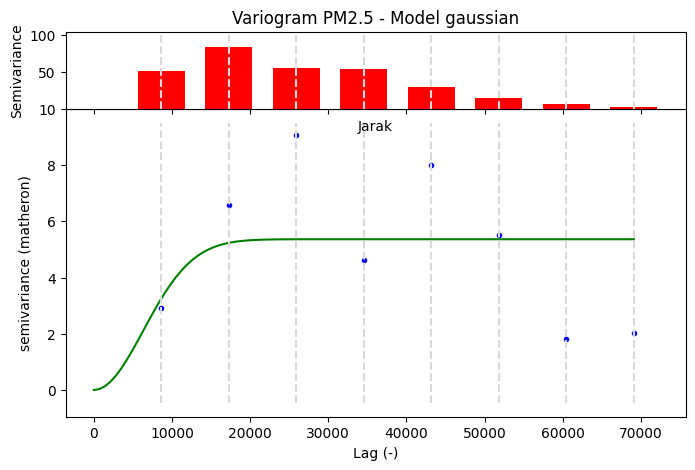

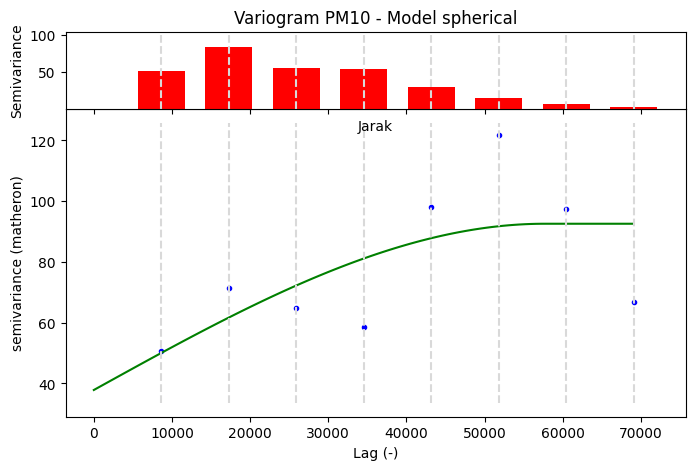


RINGKASAN SEMUA MODEL
  Variabel        Model       RMSE          RSS  \
0    PM2.5     gaussian   2.418517    46.793810   
1    PM2.5  exponential   2.541543    51.675519   
2    PM2.5       matern   2.541543    51.675519   
3    PM2.5    spherical   2.541543    51.675519   
4     PM10    spherical  17.105746  2340.852327   
5     PM10     gaussian  17.436789  2432.332959   
6     PM10       matern  17.488710  2446.839946   
7     PM10  exponential  17.921714  2569.502568   

                                           Parameter  
0  [np.float64(17881.64647005257), np.float64(5.3...  
1  [np.float64(392.2160957004089), np.float64(1.8...  
2  [np.float64(311.35559188981097), np.float64(0....  
3  [np.float64(8438.720493563356), np.float64(1.1...  
4  [np.float64(57680.1765864648), np.float64(54.7...  
5  [np.float64(62623.41713121219), np.float64(44....  
6  [np.float64(63349.94950933183), np.float64(45....  
7  [np.float64(69105.51179535856), np.float64(67....  

Hasil disimpan sebaga

In [5]:
# ============================================================
# TAHAP 3
# PEMILIHAN MODEL VARIOGRAM PM2.5 DAN PM10
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skgstat import Variogram


# ============================================================
# 1. SIAPKAN DATA
# ============================================================

# df berasal dari Tahap 2.
# Jika kernel sempat direstart, aktifkan:
# df = pd.read_csv("taiwan_air_quality_cokriging_station.csv")

coordinates = df[["X", "Y"]].values

pm25 = df["PM25"].values
pm10 = df["PM10"].values

print("Jumlah titik:", len(df))


# ============================================================
# 2. MODEL YANG AKAN DIBANDINGKAN
# ============================================================

models = [
    "spherical",
    "exponential",
    "gaussian",
    "matern"
]


# ============================================================
# 3. FUNGSI MEMBANDINGKAN MODEL
# ============================================================

def bandingkan_variogram(coordinates, values, nama_variabel):

    hasil = []
    variogram_models = {}

    for model in models:

        try:

            V = Variogram(
                coordinates,
                values,
                n_lags=8,
                model=model,
                normalize=False,
                use_nugget=True
            )

            variogram_models[model] = V

            hasil.append({
                "Variabel": nama_variabel,
                "Model": model,
                "RMSE": V.rmse,
                "RSS": V.rss,
                "Parameter": str(V.parameters)
            })

        except Exception as e:

            print(
                f"Model {model} gagal:",
                e
            )


    hasil = pd.DataFrame(hasil)

    # RMSE kecil = fitting lebih baik
    hasil = hasil.sort_values(
        "RMSE"
    ).reset_index(drop=True)

    return hasil, variogram_models


# ============================================================
# 4. BANDINGKAN MODEL PM2.5
# ============================================================

hasil_PM25, models_PM25 = bandingkan_variogram(
    coordinates,
    pm25,
    "PM2.5"
)

print("\n======================================")
print("PERBANDINGAN VARIOGRAM PM2.5")
print("======================================")

print(hasil_PM25)


# ============================================================
# 5. BANDINGKAN MODEL PM10
# ============================================================

hasil_PM10, models_PM10 = bandingkan_variogram(
    coordinates,
    pm10,
    "PM10"
)

print("\n======================================")
print("PERBANDINGAN VARIOGRAM PM10")
print("======================================")

print(hasil_PM10)


# ============================================================
# 6. MODEL DENGAN RMSE TERKECIL
# ============================================================

best_PM25 = hasil_PM25.iloc[0]["Model"]
best_PM10 = hasil_PM10.iloc[0]["Model"]

print("\n======================================")
print("MODEL DENGAN RMSE TERKECIL")
print("======================================")

print(
    "PM2.5:",
    best_PM25
)

print(
    "PM10 :",
    best_PM10
)


# ============================================================
# 7. PARAMETER MODEL TERPILIH
# ============================================================

V_PM25_best = models_PM25[best_PM25]
V_PM10_best = models_PM10[best_PM10]

print("\nParameter PM2.5:")
print(V_PM25_best.parameters)

print("\nParameter PM10:")
print(V_PM10_best.parameters)


# ============================================================
# 8. PLOT MODEL TERPILIH PM2.5
# ============================================================

V_PM25_best.plot()

plt.title(
    f"Variogram PM2.5 - Model {best_PM25}"
)

plt.xlabel("Jarak")
plt.ylabel("Semivariance")

plt.show()


# ============================================================
# 9. PLOT MODEL TERPILIH PM10
# ============================================================

V_PM10_best.plot()

plt.title(
    f"Variogram PM10 - Model {best_PM10}"
)

plt.xlabel("Jarak")
plt.ylabel("Semivariance")

plt.show()


# ============================================================
# 10. GABUNGKAN HASIL PERBANDINGAN
# ============================================================

hasil_semua = pd.concat(
    [
        hasil_PM25,
        hasil_PM10
    ],
    ignore_index=True
)

print("\n======================================")
print("RINGKASAN SEMUA MODEL")
print("======================================")

print(hasil_semua)


# ============================================================
# 11. SIMPAN HASIL
# ============================================================

hasil_semua.to_csv(
    "hasil_perbandingan_variogram.csv",
    index=False
)

print(
    "\nHasil disimpan sebagai:"
    "\nhasil_perbandingan_variogram.csv"
)

KORELASI PM2.5 DAN PM10
Pearson  : 0.314
Spearman : 0.1531

CROSS-VARIOGRAM
   Jarak_km  Cross_Semivariance  Jumlah_Pasangan
0    7.0324             -3.8774               84
1   16.4460             12.3646               88
2   28.7555              3.3764               73
3   39.4215             15.1285               38
4   50.9141             26.9635               11
5   61.8330              8.9347                6


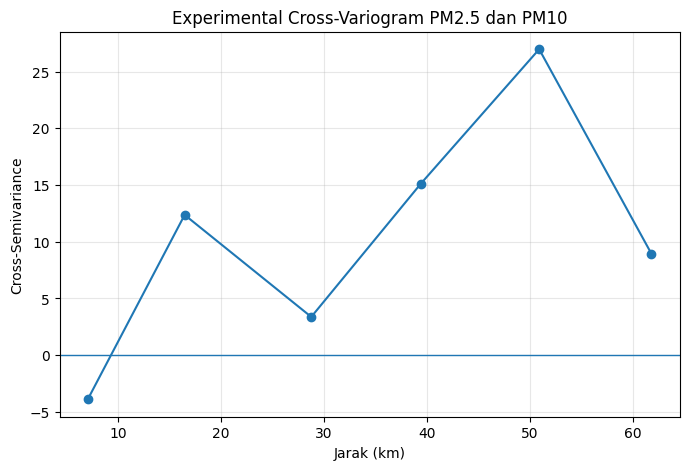

In [7]:
# ============================================================
# PEMERIKSAAN SEBELUM CO-KRIGING
# Korelasi + Cross-Variogram
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. KORELASI PM2.5 DAN PM10
# ------------------------------------------------------------

pearson = df["PM25"].corr(
    df["PM10"],
    method="pearson"
)

spearman = df["PM25"].corr(
    df["PM10"],
    method="spearman"
)

print("=" * 50)
print("KORELASI PM2.5 DAN PM10")
print("=" * 50)

print("Pearson  :", round(pearson, 4))
print("Spearman :", round(spearman, 4))


# ------------------------------------------------------------
# 2. DATA KOORDINAT DAN VARIABEL
# ------------------------------------------------------------

coords = df[["X", "Y"]].values

pm25 = df["PM25"].values
pm10 = df["PM10"].values


# ------------------------------------------------------------
# 3. HITUNG CROSS-SEMIVARIANCE
# ------------------------------------------------------------

distances = []
cross_gamma = []

n = len(df)

for i in range(n):
    for j in range(i + 1, n):

        # Jarak Euclidean
        distance = np.sqrt(
            (coords[i, 0] - coords[j, 0])**2 +
            (coords[i, 1] - coords[j, 1])**2
        )

        # Cross-semivariance
        gamma = 0.5 * (
            (pm25[i] - pm25[j]) *
            (pm10[i] - pm10[j])
        )

        distances.append(distance)
        cross_gamma.append(gamma)


distances = np.array(distances)
cross_gamma = np.array(cross_gamma)


# ------------------------------------------------------------
# 4. MEMBUAT 8 KELAS JARAK
# ------------------------------------------------------------

n_lags = 6

bins = np.linspace(
    0,
    distances.max(),
    n_lags + 1
)

lag_distance = []
mean_cross_gamma = []
jumlah_pasangan = []


for i in range(n_lags):

    # Lag terakhir dibuat <= agar jarak maksimum ikut masuk
    if i == n_lags - 1:
        mask = (
            (distances >= bins[i]) &
            (distances <= bins[i + 1])
        )
    else:
        mask = (
            (distances >= bins[i]) &
            (distances < bins[i + 1])
        )

    if mask.sum() > 0:

        lag_distance.append(
            distances[mask].mean()
        )

        mean_cross_gamma.append(
            cross_gamma[mask].mean()
        )

        jumlah_pasangan.append(
            mask.sum()
        )


# ------------------------------------------------------------
# 5. TABEL CROSS-VARIOGRAM
# ------------------------------------------------------------

cross_variogram = pd.DataFrame({
    "Jarak_km":
        np.array(lag_distance) / 1000,

    "Cross_Semivariance":
        mean_cross_gamma,

    "Jumlah_Pasangan":
        jumlah_pasangan
})


print("\n" + "=" * 50)
print("CROSS-VARIOGRAM")
print("=" * 50)

print(
    cross_variogram.round(4)
)


# ------------------------------------------------------------
# 6. PLOT CROSS-VARIOGRAM
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    np.array(lag_distance) / 1000,
    mean_cross_gamma,
    marker="o"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Jarak (km)")
plt.ylabel("Cross-Semivariance")

plt.title(
    "Experimental Cross-Variogram PM2.5 dan PM10"
)

plt.grid(alpha=0.3)

plt.show()

In [8]:
%pip install pykrige

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


DATA
Jumlah stasiun : 25
Jumlah missing : 0

Menjalankan: gaussian

Menjalankan: spherical

Menjalankan: exponential

HASIL LOOCV ORDINARY KRIGING
         Model     MAE    RMSE      ME      R2
0    spherical  1.5443  2.0650  0.0367  0.2564
1  exponential  1.5470  2.0793  0.0227  0.2460
2     gaussian  4.4625  5.9722 -0.0856 -5.2199

Model dengan RMSE terkecil:
spherical

Hasil prediksi tiap stasiun:
      station  Aktual_PM25  Prediksi_PM25  Error  Absolute_Error  \
0     Banqiao       20.259         21.275 -1.016           1.016   
1     Cailiao       15.857         17.034 -1.177           1.177   
2      Datong       17.376         18.241 -0.865           0.865   
3      Dayuan       20.534         18.767  1.767           1.767   
4     Guanyin       19.043         18.980  0.063           0.063   
5      Guting       17.005         18.534 -1.529           1.529   
6     Keelung       18.109         18.713 -0.604           0.604   
7      Linkou       20.582         19.647  0.935    

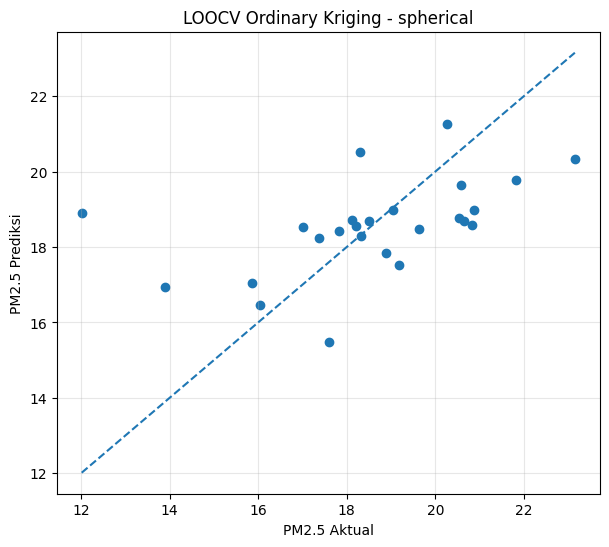


Stasiun dengan error terbesar:
      station  Aktual_PM25  Prediksi_PM25  Error  Absolute_Error
21   Yangming       12.013         18.901 -6.888           6.888
13     Tamsui       13.904         16.929 -3.026           3.026
15    Tucheng       23.154         20.326  2.827           2.827
8     Longtan       20.840         18.571  2.269           2.269
23    Zhongli       18.289         20.531 -2.242           2.242
11     Shilin       17.604         15.474  2.129           2.129
19  Xinzhuang       21.825         19.781  2.044           2.044
9    Pingzhen       20.648         18.689  1.959           1.959
14    Taoyuan       20.885         18.986  1.899           1.899
3      Dayuan       20.534         18.767  1.767           1.767

TAHAP 4A SELESAI
Model OK terbaik berdasarkan RMSE: spherical

File tersimpan:
validasi_ordinary_kriging.csv
prediksi_LOOCV_ordinary_kriging.csv
         Model     MAE    RMSE      ME      R2
0    spherical  1.5443  2.0650  0.0367  0.2564
1  exponentia

In [10]:
# ============================================================
# TAHAP 4A
# ORDINARY KRIGING PM2.5 + LOOCV
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pykrige.ok import OrdinaryKriging
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# 1. BACA DATA
# ============================================================

df = pd.read_csv(
    "taiwan_air_quality_cokriging_station.csv"
)

print("=" * 60)
print("DATA")
print("=" * 60)

print("Jumlah stasiun :", len(df))
print("Jumlah missing :", df[["X", "Y", "PM25"]].isna().sum().sum())


# ============================================================
# 2. SIAPKAN DATA
# ============================================================

X = df["X"].values
Y = df["Y"].values
PM25 = df["PM25"].values

n = len(df)


# ============================================================
# 3. FUNGSI LOOCV ORDINARY KRIGING
# ============================================================

def loocv_ok(
    X,
    Y,
    Z,
    variogram_model
):

    aktual = []
    prediksi = []
    nama_stasiun = []

    for i in range(len(Z)):

        # ----------------------------------------
        # Data training
        # Semua stasiun kecuali stasiun ke-i
        # ----------------------------------------

        mask = np.ones(
            len(Z),
            dtype=bool
        )

        mask[i] = False


        X_train = X[mask]
        Y_train = Y[mask]
        Z_train = Z[mask]


        # ----------------------------------------
        # Titik yang akan diprediksi
        # ----------------------------------------

        X_test = X[i]
        Y_test = Y[i]


        try:

            OK = OrdinaryKriging(

                X_train,
                Y_train,
                Z_train,

                variogram_model=variogram_model,

                verbose=False,
                enable_plotting=False
            )


            z_pred, z_var = OK.execute(

                "points",

                np.array([X_test]),
                np.array([Y_test])
            )


            aktual.append(
                Z[i]
            )

            prediksi.append(
                float(z_pred[0])
            )

            nama_stasiun.append(
                df.iloc[i]["station"]
            )


        except Exception as e:

            print(
                f"Gagal pada {df.iloc[i]['station']}:",
                e
            )


    hasil = pd.DataFrame({

        "station":
            nama_stasiun,

        "Aktual_PM25":
            aktual,

        "Prediksi_PM25":
            prediksi
    })


    hasil["Error"] = (
        hasil["Aktual_PM25"] -
        hasil["Prediksi_PM25"]
    )


    hasil["Absolute_Error"] = (
        np.abs(
            hasil["Error"]
        )
    )


    hasil["Squared_Error"] = (
        hasil["Error"] ** 2
    )


    # ----------------------------------------
    # METRIK
    # ----------------------------------------

    MAE = mean_absolute_error(
        aktual,
        prediksi
    )

    RMSE = np.sqrt(
        mean_squared_error(
            aktual,
            prediksi
        )
    )

    ME = np.mean(
        np.array(aktual) -
        np.array(prediksi)
    )

    R2 = r2_score(
        aktual,
        prediksi
    )


    return hasil, MAE, RMSE, ME, R2


# ============================================================
# 4. BANDINGKAN MODEL VARIOGRAM
# ============================================================

models = [
    "gaussian",
    "spherical",
    "exponential"
]

ringkasan = []

hasil_semua = {}


for model in models:

    print(
        "\nMenjalankan:",
        model
    )

    hasil, MAE, RMSE, ME, R2 = loocv_ok(

        X,
        Y,
        PM25,

        model
    )


    hasil_semua[model] = hasil


    ringkasan.append({

        "Model":
            model,

        "MAE":
            MAE,

        "RMSE":
            RMSE,

        "ME":
            ME,

        "R2":
            R2
    })


# ============================================================
# 5. TABEL HASIL
# ============================================================

ringkasan = pd.DataFrame(
    ringkasan
)

ringkasan = ringkasan.sort_values(
    "RMSE"
).reset_index(drop=True)


print("\n" + "=" * 60)
print("HASIL LOOCV ORDINARY KRIGING")
print("=" * 60)

print(
    ringkasan.round(4)
)


# ============================================================
# 6. AMBIL MODEL RMSE TERKECIL
# ============================================================

best_model = ringkasan.iloc[0]["Model"]

hasil_best = hasil_semua[
    best_model
]


print("\nModel dengan RMSE terkecil:")
print(best_model)


print("\nHasil prediksi tiap stasiun:")

print(
    hasil_best.round(3)
)


# ============================================================
# 7. SCATTER AKTUAL vs PREDIKSI
# ============================================================

plt.figure(
    figsize=(7, 6)
)

plt.scatter(

    hasil_best["Aktual_PM25"],

    hasil_best["Prediksi_PM25"]
)


minimum = min(
    hasil_best["Aktual_PM25"].min(),
    hasil_best["Prediksi_PM25"].min()
)

maximum = max(
    hasil_best["Aktual_PM25"].max(),
    hasil_best["Prediksi_PM25"].max()
)


plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)


plt.xlabel(
    "PM2.5 Aktual"
)

plt.ylabel(
    "PM2.5 Prediksi"
)

plt.title(
    f"LOOCV Ordinary Kriging - {best_model}"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 8. ERROR PER STASIUN
# ============================================================

hasil_error = hasil_best.sort_values(
    "Absolute_Error",
    ascending=False
)


print("\nStasiun dengan error terbesar:")

print(

    hasil_error[
        [
            "station",
            "Aktual_PM25",
            "Prediksi_PM25",
            "Error",
            "Absolute_Error"
        ]
    ].head(10).round(3)

)


# ============================================================
# 9. SIMPAN HASIL
# ============================================================

ringkasan.to_csv(
    "validasi_ordinary_kriging.csv",
    index=False
)

hasil_best.to_csv(
    "prediksi_LOOCV_ordinary_kriging.csv",
    index=False
)


print("\n" + "=" * 60)
print("TAHAP 4A SELESAI")
print("=" * 60)

print(
    "Model OK terbaik berdasarkan RMSE:",
    best_model
)

print(
    "\nFile tersimpan:"
)

print(
    "validasi_ordinary_kriging.csv"
)

print(
    "prediksi_LOOCV_ordinary_kriging.csv"
)

print(ringkasan.round(4))

TAHAP 4B - CO-KRIGING DENGAN LMC
Jumlah stasiun : 25

Menjalankan Co-Kriging: exponential

Menjalankan Co-Kriging: gaussian

HASIL LOOCV CO-KRIGING
         Model     MAE    RMSE      ME      R2
0  exponential  1.4839  1.8716  0.0892  0.3892
1     gaussian  3.1117  3.9098  0.1208 -1.6657

Model Co-Kriging dengan RMSE terkecil: exponential

PERBANDINGAN ORDINARY KRIGING VS CO-KRIGING
             Metode        Model     MAE    RMSE      ME      R2
0  Ordinary Kriging    spherical  1.5443  2.0650  0.0367  0.2564
1        Co-Kriging  exponential  1.4839  1.8716  0.0892  0.3892

Perubahan RMSE Co-Kriging dibanding OK:
9.37 %


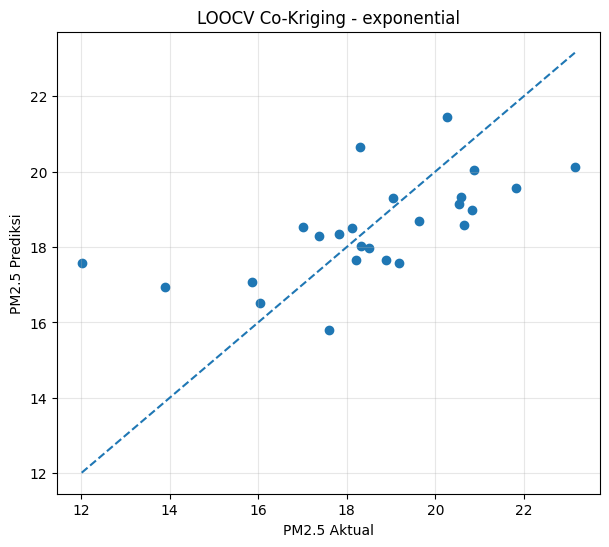


Stasiun dengan error Co-Kriging terbesar:
      station  Aktual_PM25  Prediksi_CoKriging  Error  Absolute_Error
21   Yangming       12.013              17.565 -5.553           5.553
13     Tamsui       13.904              16.936 -3.032           3.032
15    Tucheng       23.154              20.133  3.020           3.020
23    Zhongli       18.289              20.654 -2.365           2.365
19  Xinzhuang       21.825              19.559  2.266           2.266
9    Pingzhen       20.648              18.585  2.063           2.063
8     Longtan       20.840              18.977  1.863           1.863
11     Shilin       17.604              15.797  1.807           1.807
24  Zhongshan       19.183              17.569  1.614           1.614
5      Guting       17.005              18.542 -1.537           1.537

TAHAP 4B SELESAI

File tersimpan:
validasi_cokriging.csv
prediksi_LOOCV_cokriging.csv
perbandingan_OK_vs_CoKriging.csv


In [11]:
# ============================================================
# TAHAP 4B
# LINEAR MODEL OF COREGIONALIZATION (LMC)
# + CO-KRIGING
# + LEAVE-ONE-OUT CROSS VALIDATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from scipy.optimize import minimize_scalar
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. BACA DATA
# ============================================================

df = pd.read_csv(
    "taiwan_air_quality_cokriging_station.csv"
)

print("=" * 65)
print("TAHAP 4B - CO-KRIGING DENGAN LMC")
print("=" * 65)

print("Jumlah stasiun :", len(df))


# ============================================================
# 2. SIAPKAN DATA
# ============================================================

coords = df[
    ["X", "Y"]
].values.astype(float)

pm25 = df[
    "PM25"
].values.astype(float)

pm10 = df[
    "PM10"
].values.astype(float)

stations = df[
    "station"
].values


# ============================================================
# 3. FUNGSI KORELASI SPASIAL
#
# Kita uji:
# - exponential
# - gaussian
#
# h = jarak
# a = range/scale
# ============================================================

def spatial_corr(h, a, model):

    a = max(float(a), 1e-10)

    if model == "exponential":

        return np.exp(
            -h / a
        )

    elif model == "gaussian":

        return np.exp(
            -(h / a) ** 2
        )

    else:

        raise ValueError(
            "Model tidak dikenali"
        )


# ============================================================
# 4. FUNGSI ESTIMASI RANGE
#
# Range dipilih dengan pendekatan LOOCV likelihood-style
# sederhana pada PM2.5 yang sudah distandardisasi.
# ============================================================

def estimate_range(
    coordinates,
    values,
    model
):

    D = cdist(
        coordinates,
        coordinates
    )

    positive_distance = D[
        D > 0
    ]

    min_range = np.percentile(
        positive_distance,
        10
    )

    max_range = np.percentile(
        positive_distance,
        90
    )


    # standardisasi
    z = (
        values -
        np.mean(values)
    ) / np.std(
        values,
        ddof=1
    )


    def objective(a):

        R = spatial_corr(
            D,
            a,
            model
        )

        # nugget numerik kecil
        R = R + np.eye(
            len(R)
        ) * 1e-6

        try:

            sign, logdet = np.linalg.slogdet(
                R
            )

            if sign <= 0:
                return 1e20

            invR = np.linalg.inv(
                R
            )

            value = (
                logdet +
                z.T @ invR @ z
            )

            return float(value)

        except np.linalg.LinAlgError:

            return 1e20


    result = minimize_scalar(

        objective,

        bounds=(
            min_range,
            max_range
        ),

        method="bounded"
    )


    return result.x


# ============================================================
# 5. FUNGSI CO-KRIGING SATU TITIK
#
# LMC:
#
# Cov[Z_p(s), Z_q(t)]
# =
# B[p,q] * rho(h)
#
# B = matriks coregionalization
#
# Kita menggunakan residual yang sudah dicenter.
# ============================================================

def cokriging_predict(
    train_coords,
    train_pm25,
    train_pm10,
    target_coord,
    spatial_model,
    range_param
):

    n = len(
        train_pm25
    )


    # --------------------------------------------------------
    # MEAN TRAINING
    # --------------------------------------------------------

    mean25 = np.mean(
        train_pm25
    )

    mean10 = np.mean(
        train_pm10
    )


    # --------------------------------------------------------
    # RESIDUAL
    # --------------------------------------------------------

    z25 = (
        train_pm25 -
        mean25
    )

    z10 = (
        train_pm10 -
        mean10
    )


    # --------------------------------------------------------
    # COREgionalization MATRIX B
    #
    # covariance PM25 / PM10 pada training data
    # --------------------------------------------------------

    B = np.cov(
        np.vstack([
            z25,
            z10
        ]),
        ddof=1
    )


    # --------------------------------------------------------
    # JARAK ANTAR TRAINING
    # --------------------------------------------------------

    D = cdist(
        train_coords,
        train_coords
    )


    R = spatial_corr(
        D,
        range_param,
        spatial_model
    )


    # --------------------------------------------------------
    # MATRIKS KOVARIANS MULTIVARIAT
    #
    # Urutan vector:
    #
    # PM25 semua stasiun
    # PM10 semua stasiun
    # --------------------------------------------------------

    C11 = B[0, 0] * R
    C22 = B[1, 1] * R

    C12 = B[0, 1] * R
    C21 = B[1, 0] * R


    C = np.block([

        [C11, C12],

        [C21, C22]

    ])


    # nugget numerik kecil
    C = C + np.eye(
        2 * n
    ) * 1e-6


    # --------------------------------------------------------
    # KOVARIANS TARGET PM2.5
    # DENGAN DATA TRAINING
    # --------------------------------------------------------

    d0 = cdist(

        train_coords,

        np.array(
            target_coord
        ).reshape(1, -1)

    ).flatten()


    r0 = spatial_corr(
        d0,
        range_param,
        spatial_model
    )


    # covariance:
    #
    # target PM25 vs PM25
    # target PM25 vs PM10
    #

    c0_PM25 = (
        B[0, 0] *
        r0
    )

    c0_PM10 = (
        B[0, 1] *
        r0
    )


    c0 = np.concatenate([

        c0_PM25,

        c0_PM10

    ])


    # --------------------------------------------------------
    # DATA VECTOR
    # --------------------------------------------------------

    Z = np.concatenate([

        z25,

        z10

    ])


    # --------------------------------------------------------
    # SOLVE WEIGHTS
    # --------------------------------------------------------

    try:

        weights = np.linalg.solve(
            C,
            c0
        )

    except np.linalg.LinAlgError:

        weights = (
            np.linalg.pinv(C)
            @ c0
        )


    # --------------------------------------------------------
    # PREDIKSI RESIDUAL PM2.5
    # --------------------------------------------------------

    residual_prediction = (
        weights @ Z
    )


    prediction = (
        mean25 +
        residual_prediction
    )


    return float(
        prediction
    )


# ============================================================
# 6. FUNGSI LOOCV CO-KRIGING
# ============================================================

def loocv_cokriging(
    coords,
    pm25,
    pm10,
    stations,
    spatial_model
):

    actual = []
    predicted = []
    station_names = []
    ranges = []


    for i in range(
        len(pm25)
    ):


        mask = np.ones(
            len(pm25),
            dtype=bool
        )

        mask[i] = False


        train_coords = coords[
            mask
        ]

        train25 = pm25[
            mask
        ]

        train10 = pm10[
            mask
        ]


        target_coord = coords[
            i
        ]


        # ----------------------------------------------------
        # Range diestimasi ulang dari TRAINING data.
        #
        # Penting:
        # titik test tidak digunakan untuk fitting.
        # ----------------------------------------------------

        range_param = estimate_range(

            train_coords,

            train25,

            spatial_model
        )


        pred = cokriging_predict(

            train_coords,

            train25,

            train10,

            target_coord,

            spatial_model,

            range_param
        )


        actual.append(
            pm25[i]
        )

        predicted.append(
            pred
        )

        station_names.append(
            stations[i]
        )

        ranges.append(
            range_param
        )


    result = pd.DataFrame({

        "station":
            station_names,

        "Aktual_PM25":
            actual,

        "Prediksi_CoKriging":
            predicted,

        "Range_m":
            ranges
    })


    result["Error"] = (

        result["Aktual_PM25"] -

        result["Prediksi_CoKriging"]

    )


    result["Absolute_Error"] = np.abs(

        result["Error"]

    )


    # --------------------------------------------------------
    # METRIK
    # --------------------------------------------------------

    MAE = mean_absolute_error(

        actual,

        predicted

    )


    RMSE = np.sqrt(

        mean_squared_error(

            actual,

            predicted

        )

    )


    ME = np.mean(

        np.array(actual) -

        np.array(predicted)

    )


    R2 = r2_score(

        actual,

        predicted

    )


    return (
        result,
        MAE,
        RMSE,
        ME,
        R2
    )


# ============================================================
# 7. UJI MODEL SPASIAL
# ============================================================

models = [

    "exponential",

    "gaussian"

]


summary = []

all_results = {}


for model in models:

    print(
        "\nMenjalankan Co-Kriging:",
        model
    )


    (
        result,
        MAE,
        RMSE,
        ME,
        R2

    ) = loocv_cokriging(

        coords,

        pm25,

        pm10,

        stations,

        model

    )


    all_results[
        model
    ] = result


    summary.append({

        "Model":
            model,

        "MAE":
            MAE,

        "RMSE":
            RMSE,

        "ME":
            ME,

        "R2":
            R2

    })


# ============================================================
# 8. RINGKASAN CO-KRIGING
# ============================================================

summary = pd.DataFrame(
    summary
)

summary = summary.sort_values(
    "RMSE"
).reset_index(
    drop=True
)


print(
    "\n" +
    "=" * 65
)

print(
    "HASIL LOOCV CO-KRIGING"
)

print(
    "=" * 65
)


print(
    summary.round(4)
)


# ============================================================
# 9. MODEL TERBAIK BERDASARKAN RMSE
# ============================================================

best_model = summary.iloc[
    0
]["Model"]


best_result = all_results[
    best_model
]


print(
    "\nModel Co-Kriging dengan RMSE terkecil:",
    best_model
)


# ============================================================
# 10. BASELINE ORDINARY KRIGING
#
# Hasil Tahap 4A
# ============================================================

OK_MAE = 1.5443
OK_RMSE = 2.0650
OK_ME = 0.0367
OK_R2 = 0.2564


CK_MAE = summary.iloc[
    0
]["MAE"]

CK_RMSE = summary.iloc[
    0
]["RMSE"]

CK_ME = summary.iloc[
    0
]["ME"]

CK_R2 = summary.iloc[
    0
]["R2"]


comparison = pd.DataFrame({

    "Metode": [

        "Ordinary Kriging",

        "Co-Kriging"

    ],

    "Model": [

        "spherical",

        best_model

    ],

    "MAE": [

        OK_MAE,

        CK_MAE

    ],

    "RMSE": [

        OK_RMSE,

        CK_RMSE

    ],

    "ME": [

        OK_ME,

        CK_ME

    ],

    "R2": [

        OK_R2,

        CK_R2

    ]

})


print(
    "\n" +
    "=" * 65
)

print(
    "PERBANDINGAN ORDINARY KRIGING VS CO-KRIGING"
)

print(
    "=" * 65
)


print(
    comparison.round(4)
)


# ============================================================
# 11. PERUBAHAN RMSE
# ============================================================

rmse_change = (

    (
        OK_RMSE -
        CK_RMSE
    )

    /

    OK_RMSE

    * 100

)


print(
    "\nPerubahan RMSE Co-Kriging dibanding OK:"
)

print(
    round(
        rmse_change,
        2
    ),
    "%"
)


# ============================================================
# 12. AKTUAL VS PREDIKSI CO-KRIGING
# ============================================================

plt.figure(
    figsize=(7, 6)
)


plt.scatter(

    best_result[
        "Aktual_PM25"
    ],

    best_result[
        "Prediksi_CoKriging"
    ]

)


minimum = min(

    best_result[
        "Aktual_PM25"
    ].min(),

    best_result[
        "Prediksi_CoKriging"
    ].min()

)


maximum = max(

    best_result[
        "Aktual_PM25"
    ].max(),

    best_result[
        "Prediksi_CoKriging"
    ].max()

)


plt.plot(

    [minimum, maximum],

    [minimum, maximum],

    linestyle="--"

)


plt.xlabel(
    "PM2.5 Aktual"
)

plt.ylabel(
    "PM2.5 Prediksi"
)

plt.title(
    f"LOOCV Co-Kriging - {best_model}"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 13. ERROR TERBESAR
# ============================================================

error_sorted = best_result.sort_values(

    "Absolute_Error",

    ascending=False

)


print(
    "\nStasiun dengan error Co-Kriging terbesar:"
)


print(

    error_sorted[

        [
            "station",
            "Aktual_PM25",
            "Prediksi_CoKriging",
            "Error",
            "Absolute_Error"
        ]

    ]

    .head(10)

    .round(3)

)


# ============================================================
# 14. SIMPAN HASIL
# ============================================================

summary.to_csv(

    "validasi_cokriging.csv",

    index=False

)


best_result.to_csv(

    "prediksi_LOOCV_cokriging.csv",

    index=False

)


comparison.to_csv(

    "perbandingan_OK_vs_CoKriging.csv",

    index=False

)


print(
    "\n" +
    "=" * 65
)

print(
    "TAHAP 4B SELESAI"
)

print(
    "=" * 65
)


print(
    "\nFile tersimpan:"
)

print(
    "validasi_cokriging.csv"
)

print(
    "prediksi_LOOCV_cokriging.csv"
)

print(
    "perbandingan_OK_vs_CoKriging.csv"
)

In [13]:
from scipy.optimize import minimize_scalar
from scipy.spatial.distance import cdist

def estimate_range(coordinates, values, model):

    D = cdist(
        coordinates,
        coordinates
    )

    positive_distance = D[D > 0]

    min_range = np.percentile(
        positive_distance,
        10
    )

    max_range = np.percentile(
        positive_distance,
        90
    )

    z = (
        values - np.mean(values)
    ) / np.std(values, ddof=1)


    def objective(a):

        if model == "exponential":

            R = np.exp(
                -D / a
            )

        elif model == "gaussian":

            R = np.exp(
                -(D / a) ** 2
            )

        else:

            raise ValueError(
                "Model tidak dikenali"
            )


        R = R + np.eye(
            len(R)
        ) * 1e-6


        try:

            sign, logdet = np.linalg.slogdet(
                R
            )

            if sign <= 0:
                return 1e20

            invR = np.linalg.inv(
                R
            )

            return float(
                logdet +
                z.T @ invR @ z
            )

        except np.linalg.LinAlgError:

            return 1e20


    result = minimize_scalar(

        objective,

        bounds=(
            min_range,
            max_range
        ),

        method="bounded"
    )


    return result.x

TAHAP 5 - PEMETAAN CO-KRIGING
Jumlah stasiun: 25
Range parameter: 8.93 km
Mean PM2.5: 18.583
Mean PM10: 41.781

Coregionalization Matrix:
[[ 5.9733  6.4465]
 [ 6.4465 70.5544]]

Jumlah grid awal: 22500
Grid dalam convex hull: 11378

Prediksi selesai.
PM2.5 minimum: 12.2
PM2.5 maksimum: 23.084


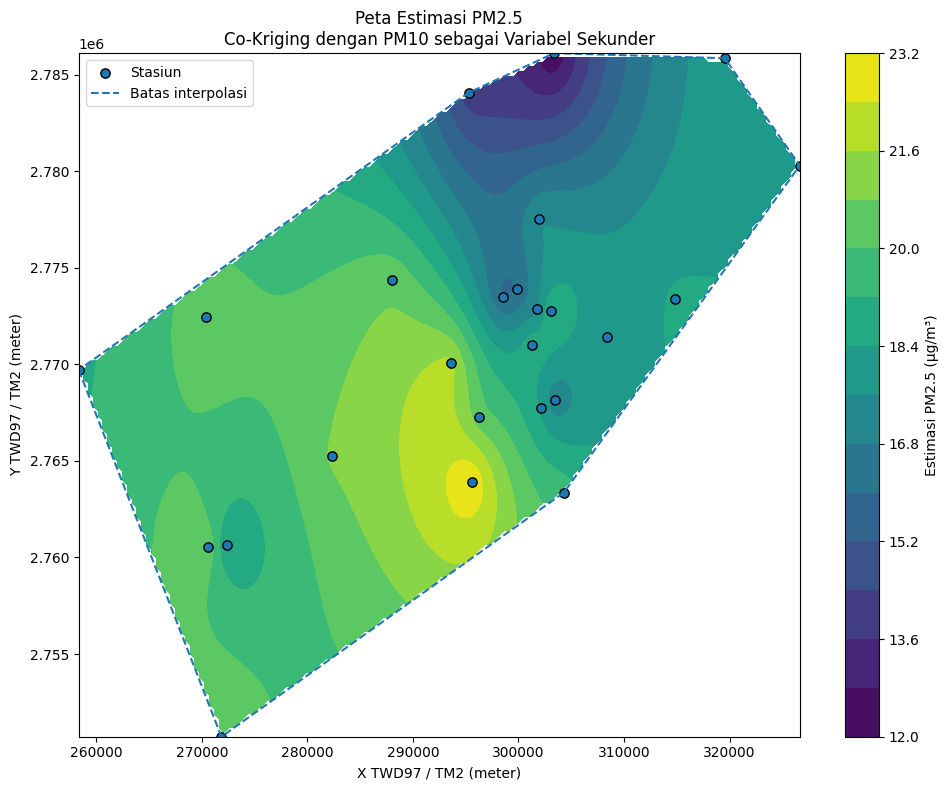

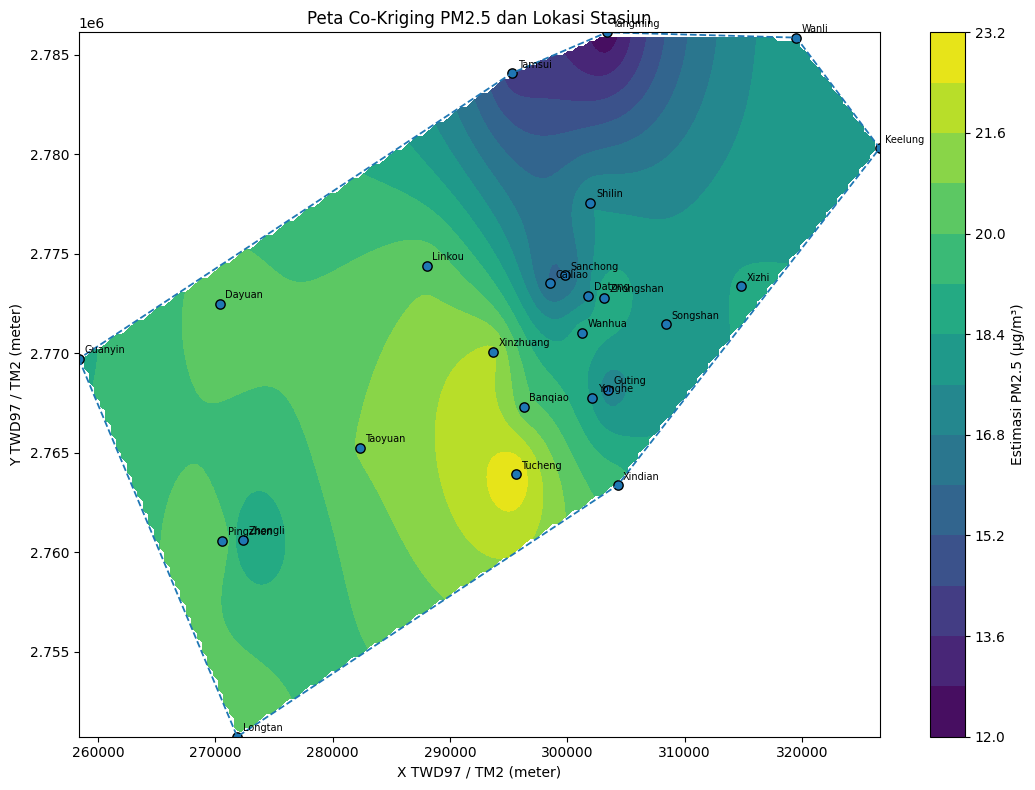


File hasil grid tersimpan:
hasil_grid_cokriging_PM25.csv

TAHAP 5 SELESAI


In [14]:
# ============================================================
# TAHAP 5
# PEMETAAN PM2.5 DENGAN CO-KRIGING
# MODEL: EXPONENTIAL
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from scipy.spatial import ConvexHull
from matplotlib.path import Path


# ============================================================
# 1. BACA DATA
# ============================================================

df = pd.read_csv(
    "taiwan_air_quality_cokriging_station.csv"
)

coords = df[
    ["X", "Y"]
].values.astype(float)

pm25 = df[
    "PM25"
].values.astype(float)

pm10 = df[
    "PM10"
].values.astype(float)


print("=" * 60)
print("TAHAP 5 - PEMETAAN CO-KRIGING")
print("=" * 60)

print("Jumlah stasiun:", len(df))


# ============================================================
# 2. FUNGSI KORELASI EXPONENTIAL
# ============================================================

def spatial_corr(h, a):

    a = max(
        float(a),
        1e-10
    )

    return np.exp(
        -h / a
    )


# ============================================================
# 3. ESTIMASI RANGE
#
# Menggunakan fungsi estimate_range dari Tahap 4B.
# Jika fungsi tersebut masih aktif di notebook,
# bagian ini langsung dapat digunakan.
# ============================================================

range_param = estimate_range(
    coords,
    pm25,
    "exponential"
)

print(
    "Range parameter:",
    round(range_param / 1000, 3),
    "km"
)


# ============================================================
# 4. CENTERING DATA
# ============================================================

mean25 = np.mean(pm25)
mean10 = np.mean(pm10)

z25 = pm25 - mean25
z10 = pm10 - mean10


print(
    "Mean PM2.5:",
    round(mean25, 3)
)

print(
    "Mean PM10:",
    round(mean10, 3)
)


# ============================================================
# 5. COREgionalization MATRIX
# ============================================================

B = np.cov(
    np.vstack([
        z25,
        z10
    ]),
    ddof=1
)


print("\nCoregionalization Matrix:")
print(
    np.round(B, 4)
)


# ============================================================
# 6. MATRIKS JARAK ANTAR STASIUN
# ============================================================

D = cdist(
    coords,
    coords
)


# ============================================================
# 7. MATRIKS KORELASI SPASIAL
# ============================================================

R = spatial_corr(
    D,
    range_param
)


# ============================================================
# 8. MATRIKS KOVARIANS LMC
# ============================================================

C11 = B[0, 0] * R

C22 = B[1, 1] * R

C12 = B[0, 1] * R

C21 = B[1, 0] * R


C = np.block([

    [C11, C12],

    [C21, C22]

])


# stabilitas numerik
C = C + np.eye(
    len(C)
) * 1e-6


# ============================================================
# 9. DATA VECTOR
# ============================================================

Z = np.concatenate([

    z25,

    z10

])


# ============================================================
# 10. INVERSE / PSEUDOINVERSE
#
# Dihitung satu kali supaya prediksi grid lebih cepat.
# ============================================================

try:

    C_inv = np.linalg.inv(C)

except np.linalg.LinAlgError:

    print(
        "Menggunakan pseudoinverse."
    )

    C_inv = np.linalg.pinv(C)


# ============================================================
# 11. MEMBUAT CONVEX HULL
# ============================================================

hull = ConvexHull(
    coords
)

hull_points = coords[
    hull.vertices
]


# tutup polygon
hull_polygon = np.vstack([

    hull_points,

    hull_points[0]

])


# ============================================================
# 12. MEMBUAT GRID
#
# Resolusi 150 x 150 cukup untuk visualisasi.
# ============================================================

grid_size = 150


x_grid = np.linspace(

    coords[:, 0].min(),

    coords[:, 0].max(),

    grid_size

)


y_grid = np.linspace(

    coords[:, 1].min(),

    coords[:, 1].max(),

    grid_size

)


grid_x, grid_y = np.meshgrid(

    x_grid,

    y_grid

)


grid_points = np.column_stack([

    grid_x.ravel(),

    grid_y.ravel()

])


print(
    "\nJumlah grid awal:",
    len(grid_points)
)


# ============================================================
# 13. MASK CONVEX HULL
#
# Hanya titik yang berada di dalam area stasiun.
# ============================================================

polygon = Path(
    hull_points
)


inside = polygon.contains_points(
    grid_points,
    radius=1e-9
)


valid_grid = grid_points[
    inside
]


print(
    "Grid dalam convex hull:",
    len(valid_grid)
)


# ============================================================
# 14. FUNGSI PREDIKSI CO-KRIGING
# ============================================================

def predict_grid_point(
    target_coord
):

    # ------------------------------------------
    # jarak target ke semua stasiun
    # ------------------------------------------

    d0 = cdist(

        coords,

        np.array(
            target_coord
        ).reshape(1, -1)

    ).flatten()


    # ------------------------------------------
    # korelasi spasial
    # ------------------------------------------

    r0 = spatial_corr(

        d0,

        range_param

    )


    # ------------------------------------------
    # covariance target PM2.5
    # terhadap PM2.5 observasi
    # ------------------------------------------

    c_pm25 = (
        B[0, 0]
        * r0
    )


    # ------------------------------------------
    # covariance target PM2.5
    # terhadap PM10 observasi
    # ------------------------------------------

    c_pm10 = (
        B[0, 1]
        * r0
    )


    c0 = np.concatenate([

        c_pm25,

        c_pm10

    ])


    # ------------------------------------------
    # weights
    # ------------------------------------------

    weights = (
        C_inv @ c0
    )


    # ------------------------------------------
    # prediksi
    # ------------------------------------------

    residual_prediction = (
        weights @ Z
    )


    prediction = (

        mean25 +

        residual_prediction

    )


    return float(
        prediction
    )


# ============================================================
# 15. PREDIKSI SELURUH GRID
# ============================================================

predictions = []


for point in valid_grid:

    pred = predict_grid_point(
        point
    )

    predictions.append(
        pred
    )


predictions = np.array(
    predictions
)


print("\nPrediksi selesai.")

print(
    "PM2.5 minimum:",
    round(predictions.min(), 3)
)

print(
    "PM2.5 maksimum:",
    round(predictions.max(), 3)
)


# ============================================================
# 16. MASUKKAN PREDIKSI KE GRID
# ============================================================

prediction_grid = np.full(

    grid_x.shape,

    np.nan

)


prediction_flat = prediction_grid.ravel()


prediction_flat[
    inside
] = predictions


prediction_grid = prediction_flat.reshape(
    grid_x.shape
)


# ============================================================
# 17. PETA CO-KRIGING
# ============================================================

plt.figure(
    figsize=(10, 8)
)


contour = plt.contourf(

    grid_x,

    grid_y,

    prediction_grid,

    levels=15
)


# colorbar
cbar = plt.colorbar(
    contour
)

cbar.set_label(
    "Estimasi PM2.5 (µg/m³)"
)


# lokasi stasiun
plt.scatter(

    coords[:, 0],

    coords[:, 1],

    edgecolor="black",

    s=45,

    label="Stasiun"
)


# batas convex hull
plt.plot(

    hull_polygon[:, 0],

    hull_polygon[:, 1],

    linestyle="--",

    linewidth=1.5,

    label="Batas interpolasi"
)


plt.xlabel(
    "X TWD97 / TM2 (meter)"
)

plt.ylabel(
    "Y TWD97 / TM2 (meter)"
)


plt.title(
    "Peta Estimasi PM2.5\n"
    "Co-Kriging dengan PM10 sebagai Variabel Sekunder"
)


plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 18. PETA + NAMA STASIUN
# ============================================================

plt.figure(
    figsize=(11, 8)
)


contour = plt.contourf(

    grid_x,

    grid_y,

    prediction_grid,

    levels=15
)


cbar = plt.colorbar(
    contour
)

cbar.set_label(
    "Estimasi PM2.5 (µg/m³)"
)


plt.scatter(

    coords[:, 0],

    coords[:, 1],

    edgecolor="black",

    s=45
)


for i, row in df.iterrows():

    plt.annotate(

        row["station"],

        (
            row["X"],
            row["Y"]
        ),

        xytext=(4, 4),

        textcoords="offset points",

        fontsize=7
    )


plt.plot(

    hull_polygon[:, 0],

    hull_polygon[:, 1],

    linestyle="--",

    linewidth=1.3
)


plt.xlabel(
    "X TWD97 / TM2 (meter)"
)

plt.ylabel(
    "Y TWD97 / TM2 (meter)"
)


plt.title(
    "Peta Co-Kriging PM2.5 dan Lokasi Stasiun"
)


plt.tight_layout()

plt.show()


# ============================================================
# 19. SIMPAN HASIL GRID
# ============================================================

hasil_grid = pd.DataFrame({

    "X":
        valid_grid[:, 0],

    "Y":
        valid_grid[:, 1],

    "PM25_CoKriging":
        predictions

})


hasil_grid.to_csv(

    "hasil_grid_cokriging_PM25.csv",

    index=False

)


print(
    "\nFile hasil grid tersimpan:"
)

print(
    "hasil_grid_cokriging_PM25.csv"
)


print(
    "\n" +
    "=" * 60
)

print(
    "TAHAP 5 SELESAI"
)

print(
    "=" * 60
)

TAHAP 6 - RANGKUMAN HASIL ANALISIS

TABEL DATA 25 STASIUN
  Stasiun  Longitude  Latitude          X           Y  PM2.5   PM10  Jumlah_Observasi
  Banqiao    121.459    25.013 296293.303 2767292.715 20.259 44.209              8398
  Cailiao    121.481    25.069 298528.200 2773500.941 15.857 38.679              8470
   Datong    121.513    25.063 301787.522 2772876.013 17.376 53.307              8575
   Dayuan    121.202    25.060 270360.868 2772476.590 20.534 46.988              8459
  Guanyin    121.083    25.036 258351.495 2769712.502 19.043 50.851              8274
   Guting    121.530    25.021 303444.953 2768164.608 17.005 45.333              8376
  Keelung    121.760    25.129 326641.095 2780300.339 18.109 30.603              8266
   Linkou    121.377    25.077 288017.529 2774381.081 20.582 42.272              8313
  Longtan    121.216    24.864 271862.402 2750716.941 20.840 46.769              8603
 Pingzhen    121.204    24.953 270598.236 2760563.541 20.648 47.059              8

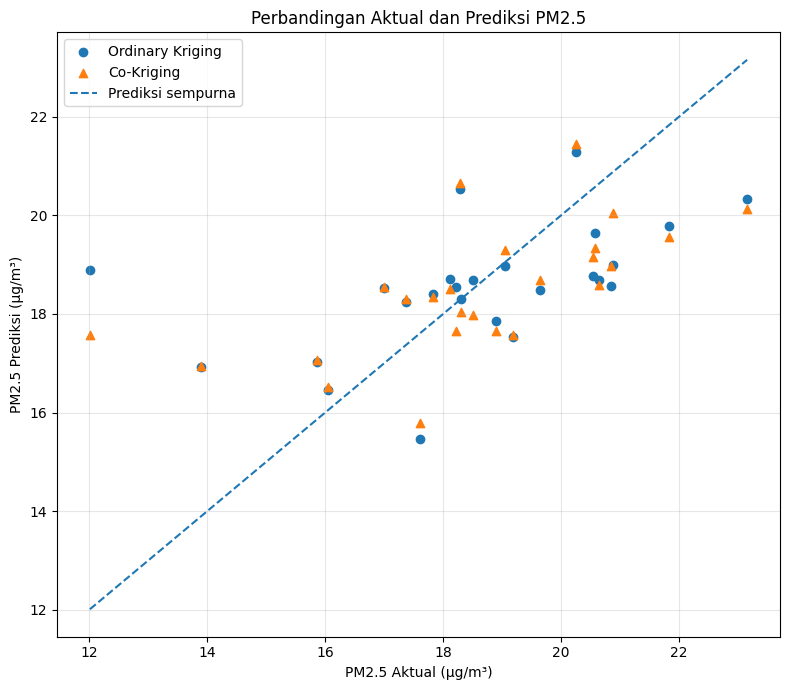

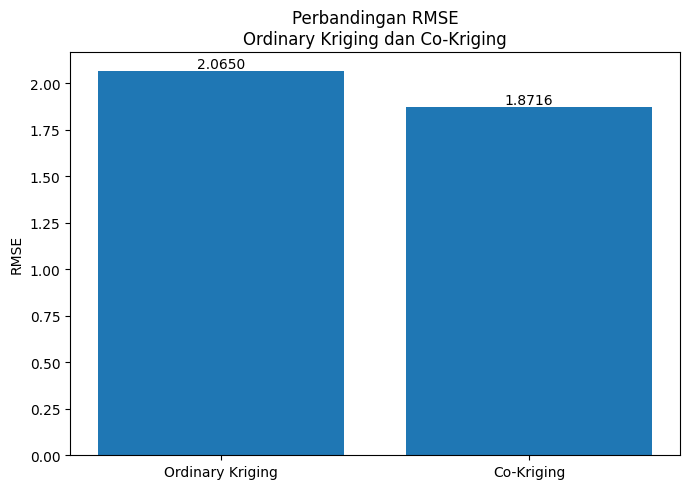

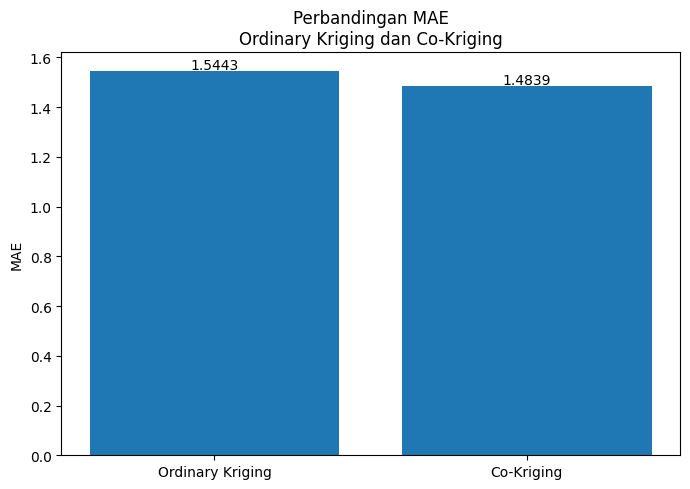


HASIL INTERPOLASI CO-KRIGING
Jumlah titik grid: 11378
Minimum estimasi PM2.5: 12.2
Maksimum estimasi PM2.5: 23.084
Rata-rata estimasi PM2.5: 19.052

TAHAP 6 SELESAI

File yang dihasilkan:

1. Tabel_25_Stasiun.csv
2. Statistik_Deskriptif.csv
3. Validasi_OK_vs_CoKriging.csv
4. Aktual_vs_Prediksi.csv
5. Hasil_Final_CoKriging.xlsx
6. grafik_aktual_vs_prediksi.png
7. perbandingan_RMSE.png
8. perbandingan_MAE.png



In [15]:
# ============================================================
# TAHAP 6
# OUTPUT FINAL ANALISIS CO-KRIGING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. BACA DATA DAN HASIL ANALISIS
# ============================================================

df = pd.read_csv(
    "taiwan_air_quality_cokriging_station.csv"
)

hasil_ck = pd.read_csv(
    "prediksi_LOOCV_cokriging.csv"
)

hasil_ok = pd.read_csv(
    "prediksi_LOOCV_ordinary_kriging.csv"
)

grid_ck = pd.read_csv(
    "hasil_grid_cokriging_PM25.csv"
)


print("=" * 70)
print("TAHAP 6 - RANGKUMAN HASIL ANALISIS")
print("=" * 70)


# ============================================================
# 2. TABEL DATA 25 STASIUN
# ============================================================

tabel_stasiun = df[
    [
        "station",
        "longitude",
        "latitude",
        "X",
        "Y",
        "PM25",
        "PM10",
        "jumlah_observasi"
    ]
].copy()


tabel_stasiun.columns = [
    "Stasiun",
    "Longitude",
    "Latitude",
    "X",
    "Y",
    "PM2.5",
    "PM10",
    "Jumlah_Observasi"
]


print("\n" + "=" * 70)
print("TABEL DATA 25 STASIUN")
print("=" * 70)

print(
    tabel_stasiun.round(3).to_string(index=False)
)


# ============================================================
# 3. STATISTIK DESKRIPTIF
# ============================================================

statistik = pd.DataFrame({

    "Statistik": [
        "Jumlah Stasiun",
        "Mean",
        "Median",
        "Standar Deviasi",
        "Minimum",
        "Maksimum"
    ],

    "PM2.5": [
        len(df),
        df["PM25"].mean(),
        df["PM25"].median(),
        df["PM25"].std(),
        df["PM25"].min(),
        df["PM25"].max()
    ],

    "PM10": [
        len(df),
        df["PM10"].mean(),
        df["PM10"].median(),
        df["PM10"].std(),
        df["PM10"].min(),
        df["PM10"].max()
    ]
})


print("\n" + "=" * 70)
print("STATISTIK DESKRIPTIF")
print("=" * 70)

print(
    statistik.round(3).to_string(index=False)
)


# ============================================================
# 4. KORELASI PM2.5 DAN PM10
# ============================================================

pearson = df["PM25"].corr(
    df["PM10"],
    method="pearson"
)

spearman = df["PM25"].corr(
    df["PM10"],
    method="spearman"
)


print("\n" + "=" * 70)
print("KORELASI")
print("=" * 70)

print(
    "Pearson  :",
    round(pearson, 4)
)

print(
    "Spearman :",
    round(spearman, 4)
)


# ============================================================
# 5. TABEL VALIDASI MODEL
# ============================================================

validasi = pd.DataFrame({

    "Metode": [
        "Ordinary Kriging",
        "Co-Kriging"
    ],

    "Model": [
        "Spherical",
        "Exponential"
    ],

    "MAE": [
        1.5443,
        1.4839
    ],

    "RMSE": [
        2.0650,
        1.8716
    ],

    "ME": [
        0.0367,
        0.0892
    ],

    "R2": [
        0.2564,
        0.3892
    ]
})


print("\n" + "=" * 70)
print("PERBANDINGAN VALIDASI MODEL")
print("=" * 70)

print(
    validasi.to_string(index=False)
)


# ============================================================
# 6. HITUNG PERUBAHAN ERROR
# ============================================================

rmse_ok = 2.0650
rmse_ck = 1.8716

mae_ok = 1.5443
mae_ck = 1.4839


penurunan_rmse = (
    (rmse_ok - rmse_ck)
    / rmse_ok
) * 100


penurunan_mae = (
    (mae_ok - mae_ck)
    / mae_ok
) * 100


print("\nPenurunan RMSE :",
      round(penurunan_rmse, 2),
      "%")

print("Penurunan MAE  :",
      round(penurunan_mae, 2),
      "%")


# ============================================================
# 7. GABUNGKAN HASIL PREDIKSI OK DAN CO-KRIGING
# ============================================================

# Ambil kolom penting
perbandingan_prediksi = pd.DataFrame({

    "Stasiun":
        hasil_ck["station"],

    "PM25_Aktual":
        hasil_ck["Aktual_PM25"],

    "Prediksi_OK":
        hasil_ok["Prediksi_PM25"],

    "Prediksi_CoKriging":
        hasil_ck["Prediksi_CoKriging"]

})


perbandingan_prediksi["Error_OK"] = (

    perbandingan_prediksi["PM25_Aktual"]
    -
    perbandingan_prediksi["Prediksi_OK"]

)


perbandingan_prediksi["Error_CoKriging"] = (

    perbandingan_prediksi["PM25_Aktual"]
    -
    perbandingan_prediksi["Prediksi_CoKriging"]

)


perbandingan_prediksi["Absolute_Error_OK"] = (

    np.abs(
        perbandingan_prediksi["Error_OK"]
    )

)


perbandingan_prediksi["Absolute_Error_CoKriging"] = (

    np.abs(
        perbandingan_prediksi["Error_CoKriging"]
    )

)


print("\n" + "=" * 70)
print("AKTUAL VS PREDIKSI")
print("=" * 70)

print(
    perbandingan_prediksi.round(3).to_string(index=False)
)


# ============================================================
# 8. STASIUN DENGAN ERROR CO-KRIGING TERBESAR
# ============================================================

error_ck = perbandingan_prediksi.sort_values(

    "Absolute_Error_CoKriging",

    ascending=False
)


print("\n" + "=" * 70)
print("5 ERROR CO-KRIGING TERBESAR")
print("=" * 70)

print(

    error_ck[
        [
            "Stasiun",
            "PM25_Aktual",
            "Prediksi_CoKriging",
            "Error_CoKriging",
            "Absolute_Error_CoKriging"
        ]
    ]
    .head(5)
    .round(3)
    .to_string(index=False)

)


# ============================================================
# 9. GRAFIK AKTUAL VS PREDIKSI
# ============================================================

plt.figure(
    figsize=(8, 7)
)


plt.scatter(

    perbandingan_prediksi["PM25_Aktual"],

    perbandingan_prediksi["Prediksi_OK"],

    marker="o",

    label="Ordinary Kriging"
)


plt.scatter(

    perbandingan_prediksi["PM25_Aktual"],

    perbandingan_prediksi["Prediksi_CoKriging"],

    marker="^",

    label="Co-Kriging"
)


minimum = min(

    perbandingan_prediksi[
        [
            "PM25_Aktual",
            "Prediksi_OK",
            "Prediksi_CoKriging"
        ]
    ].min()

)


maximum = max(

    perbandingan_prediksi[
        [
            "PM25_Aktual",
            "Prediksi_OK",
            "Prediksi_CoKriging"
        ]
    ].max()

)


plt.plot(

    [minimum, maximum],

    [minimum, maximum],

    linestyle="--",

    label="Prediksi sempurna"
)


plt.xlabel(
    "PM2.5 Aktual (µg/m³)"
)

plt.ylabel(
    "PM2.5 Prediksi (µg/m³)"
)

plt.title(
    "Perbandingan Aktual dan Prediksi PM2.5"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "grafik_aktual_vs_prediksi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. GRAFIK PERBANDINGAN RMSE
# ============================================================

plt.figure(
    figsize=(7, 5)
)


plt.bar(

    validasi["Metode"],

    validasi["RMSE"]
)


plt.ylabel(
    "RMSE"
)

plt.title(
    "Perbandingan RMSE\nOrdinary Kriging dan Co-Kriging"
)


for i, value in enumerate(
    validasi["RMSE"]
):

    plt.text(

        i,

        value + 0.02,

        f"{value:.4f}",

        ha="center"
    )


plt.tight_layout()

plt.savefig(
    "perbandingan_RMSE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. GRAFIK PERBANDINGAN MAE
# ============================================================

plt.figure(
    figsize=(7, 5)
)


plt.bar(

    validasi["Metode"],

    validasi["MAE"]
)


plt.ylabel(
    "MAE"
)

plt.title(
    "Perbandingan MAE\nOrdinary Kriging dan Co-Kriging"
)


for i, value in enumerate(
    validasi["MAE"]
):

    plt.text(

        i,

        value + 0.01,

        f"{value:.4f}",

        ha="center"
    )


plt.tight_layout()

plt.savefig(
    "perbandingan_MAE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. INFORMASI HASIL INTERPOLASI
# ============================================================

print("\n" + "=" * 70)
print("HASIL INTERPOLASI CO-KRIGING")
print("=" * 70)

print(
    "Jumlah titik grid:",
    len(grid_ck)
)

print(
    "Minimum estimasi PM2.5:",
    round(
        grid_ck["PM25_CoKriging"].min(),
        3
    )
)

print(
    "Maksimum estimasi PM2.5:",
    round(
        grid_ck["PM25_CoKriging"].max(),
        3
    )
)

print(
    "Rata-rata estimasi PM2.5:",
    round(
        grid_ck["PM25_CoKriging"].mean(),
        3
    )
)


# ============================================================
# 13. SIMPAN TABEL FINAL
# ============================================================

tabel_stasiun.to_csv(

    "Tabel_25_Stasiun.csv",

    index=False

)


statistik.to_csv(

    "Statistik_Deskriptif.csv",

    index=False

)


validasi.to_csv(

    "Validasi_OK_vs_CoKriging.csv",

    index=False

)


perbandingan_prediksi.to_csv(

    "Aktual_vs_Prediksi.csv",

    index=False

)


# ============================================================
# 14. BUAT FILE EXCEL RANGKUMAN
# ============================================================

with pd.ExcelWriter(
    "Hasil_Final_CoKriging.xlsx"
) as writer:

    tabel_stasiun.to_excel(
        writer,
        sheet_name="Data Stasiun",
        index=False
    )

    statistik.to_excel(
        writer,
        sheet_name="Statistik Deskriptif",
        index=False
    )

    validasi.to_excel(
        writer,
        sheet_name="Validasi Model",
        index=False
    )

    perbandingan_prediksi.to_excel(
        writer,
        sheet_name="Aktual vs Prediksi",
        index=False
    )

    grid_ck.to_excel(
        writer,
        sheet_name="Grid CoKriging",
        index=False
    )


print("\n" + "=" * 70)
print("TAHAP 6 SELESAI")
print("=" * 70)

print("""
File yang dihasilkan:

1. Tabel_25_Stasiun.csv
2. Statistik_Deskriptif.csv
3. Validasi_OK_vs_CoKriging.csv
4. Aktual_vs_Prediksi.csv
5. Hasil_Final_CoKriging.xlsx
6. grafik_aktual_vs_prediksi.png
7. perbandingan_RMSE.png
8. perbandingan_MAE.png
""")